In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

$$
\frac{\partial u}{\partial t}
=
\alpha^2
\frac{\partial^2 u}{\partial x^2},
$$

In [6]:
def thomas_algorithm(a,b,d,B):
    N = len(d)

    y = np.zeros(N)

    a[0] = a[0]/d[0]
    B[0] = B[0]/d[0]

    for i in range(1, N-1):
        a[i] = a[i]/(d[i] - b[i-1]*a[i-1])
        B[i] = (B[i] - b[i-1]*B[i-1])/(d[i] - b[i-1]*a[i-1])

    B[N-1] = (B[N-1] - b[N-2]*B[N-2])/(d[N-1] - b[N-2]*a[N-2])

    y[N-1] = B[N-1]

    for i in range(N-2, -1, -1):
        y[i] = B[i] - a[i]*y[i+1]

    return y

Método explícito:

In [12]:
def F(x):
    return -1.04*5 / (10.6 * 0.056)

def f(x):
    return np.sin(np.pi*x / 1.5)

In [15]:
from matplotlib.lines import lineStyles
from mpl_toolkits.mplot3d import Axes3D
def plot_grafico(x,t,w):
  plt.figure(figsize = (15,8))
  X, Y = np.meshgrid(x, t) # Changed from np.meshgrid(x, y) to np.meshgrid(x, t)
  X_real,Y_real = np.meshgrid(x, t) # Changed to use the same x and t as the numerical solution for consistency

  fig = plt.figure()
  ax = fig.add_subplot(111, projection='3d')

  ax.plot_surface(X, Y, w.T, cmap='viridis', alpha=0.6, label='Numérico')

  ax.set_xlabel('x')
  ax.set_ylabel('y')
  ax.set_zlabel('w')
  plt.legend()
  plt.show()

In [16]:
def parabolica_explicito(l, T, m, n, f):

    h = l/m
    k = T/n
    K = 1.04
    rho = 10.6
    L = 1.5
    C = 0.056
    r = 5

    alpha = 1/K
    lamb = alpha*k/ h**2

    x = np.linspace(0, l, m+1)
    t = np.linspace(0, T, n+1)

    # espaço x tempo
    w = np.zeros((m+1, n+1))

    # condição inicial
    for i in range(m+1):
        w[i,0] = f(x[i])

    # avanço temporal
    for j in range(n):
        for i in range(1, m):
            w[i,j + 1] = (
                (1-2*lamb)*w[i,j]
                + (lamb)*(w[i+1,j] + w[i-1,j]) + k*r /(rho*C)
            )

        w[0,j+1] = 0
        w[m,j+1] = 0

    return x, t, w

In [17]:
x,t,w =  parabolica_explicito(1.5, 1, 10, 10, f)

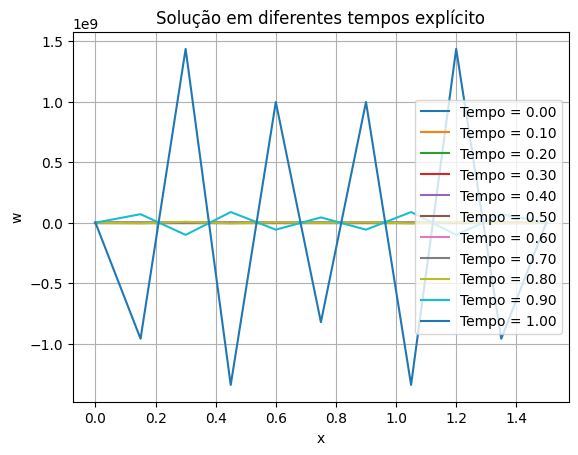

In [11]:
for j in range(len(t)):
  plt.plot(x, w[:, j], label=f'Tempo = {t[j]:.2f}')
plt.xlabel('x')
plt.ylabel('w')
plt.title('Solução em diferentes tempos explícito')
plt.legend()
plt.grid()
plt.show()


<Figure size 1500x800 with 0 Axes>

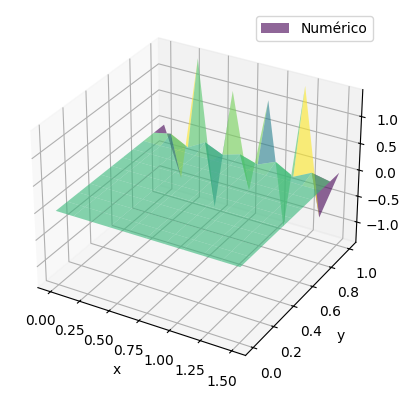

In [18]:
plot_grafico(x,t,w)